In [1]:
#Instalujemy biblioteki
!pip install yfinance
!pip install numpy==1.26.4
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt


  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-ta 0.4.71b0 requires numpy>=2.2.6, but you have numpy 1.26.4 which is incompatible.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.3 which is incompatible.
C:\Users\karol\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\karol\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
!pip install numpy==1.26.4 scipy scikit-learn
!pip install --upgrade numpy pandas
!pip install --upgrade yfinance pandas-ta

  Using cached numpy-2.4.6-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------------------- ----- 10.7/12.3 MB 61.0 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 38.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.4.6 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.4.6 which is incompatible.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.4.6 which is incompatible.
scipy 1.13.1 requires numpy<2.3,>=1.22.4, but you have numpy 2.4.6 which is incompatible.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.3 which is incompatible.


  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.3 which is incompatible.


In [3]:
#Pobieramy dane S&P500
sp500 = yf.download('^GSPC', period='5y')

[*********************100%***********************]  1 of 1 completed


In [4]:
print("\nOto najświeższe dane (OHLCV):")
print(sp500.tail())


Oto najświeższe dane (OHLCV):
Price             Close         High          Low         Open      Volume
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC
Date                                                                      
2026-05-14  7501.240234  7517.120117  7454.399902  7454.399902  5267050000
2026-05-15  7408.500000  7454.850098  7397.500000  7445.109863  5582070000
2026-05-18  7403.049805  7434.060059  7353.169922  7415.069824  5489500000
2026-05-19  7353.609863  7395.319824  7333.680176  7375.750000  5441140000
2026-05-20  7431.569824  7435.689941  7357.459961  7369.189941  2200149000


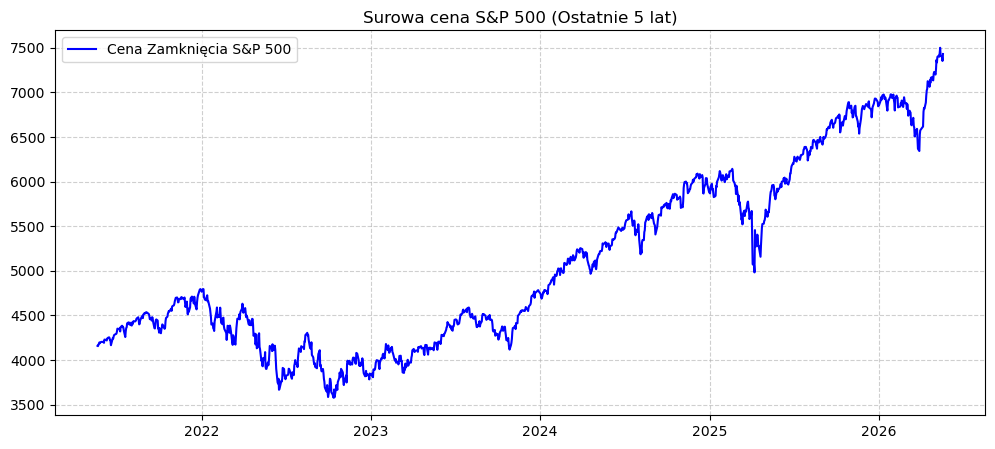

In [5]:
plt.figure(figsize=(12,5))
plt.plot(sp500['Close'], label='Cena Zamknięcia S&P 500', color='blue')
plt.title('Surowa cena S&P 500 (Ostatnie 5 lat)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [6]:
#Przeprowadzamy test ADF
!pip install --upgrade statsmodels "numpy<2.0.0"

  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-ta 0.4.71b0 requires numpy>=2.2.6, but you have numpy 1.26.4 which is incompatible.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.3 which is incompatible.


In [7]:
from statsmodels.tsa.stattools import adfuller

In [8]:
sp500_new = sp500["Close"].dropna()
adf = adfuller(sp500_new)
print("The p value is", adf[1])
print("Szereg czasowy jest Niestacjonarny")

The p value is 0.9884123557729612
Szereg czasowy jest Niestacjonarny


In [9]:
#Przekształcamy cene w zwroty procentowe żeby wyeliminować niestacjonarność
sp500_zwroty = sp500_new.pct_change().dropna()
adf_zwroty = adfuller(sp500_zwroty)
print("P value wynosi", adf_zwroty[1])
print("Nasz szereg czasowy jest teraz stacjonarny")

P value wynosi 0.0
Nasz szereg czasowy jest teraz stacjonarny


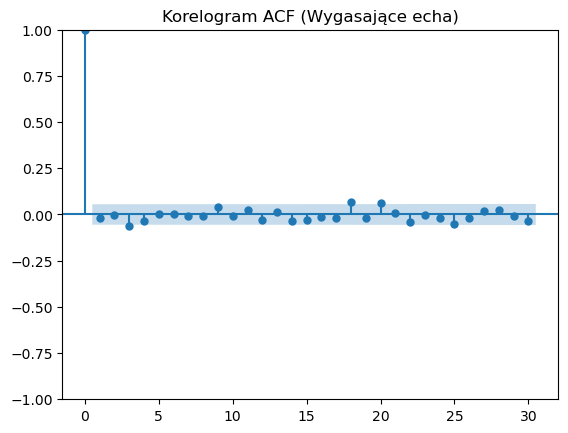

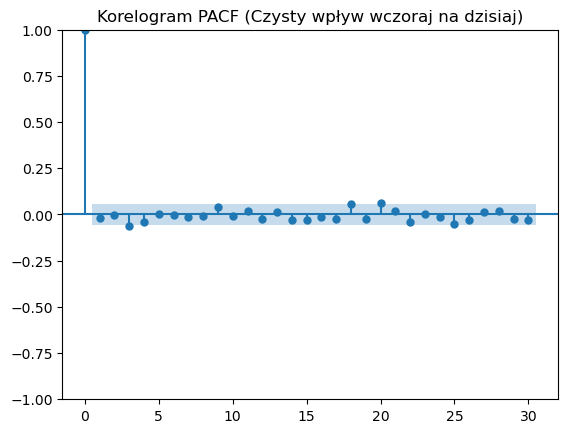

In [10]:
#Używamy ACF i PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plot_acf(sp500_zwroty, lags=30)
plt.title('Korelogram ACF (Wygasające echa)')
plt.show()

plot_pacf(sp500_zwroty, lags=30)
plt.title('Korelogram PACF (Czysty wpływ wczoraj na dzisiaj)')
plt.show()

In [11]:
#Tworzymy model ARIMA (1.1.1)
from statsmodels.tsa.arima.model import ARIMA
model_arima = ARIMA(sp500_new, order=(1, 1, 1))
wynik_arima = model_arima.fit()
print(wynik_arima.summary())

C:\Users\karol\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\karol\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\karol\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\karol\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive pa

                               SARIMAX Results                                
Dep. Variable:                  ^GSPC   No. Observations:                 1256
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -6734.462
Date:                Wed, 20 May 2026   AIC                          13474.924
Time:                        21:48:31   BIC                          13490.328
Sample:                             0   HQIC                         13480.714
                               - 1256                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6440      0.395     -1.631      0.103      -1.418       0.130
ma.L1          0.6174      0.402      1.534      0.125      -0.171       1.406
sigma2      2678.9729     49.086     54.577      0.0

In [12]:
#Instalujemy wskaźniki analizy technicznej 
!pip install pandas_ta


  Using cached numpy-2.4.6-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.3 which is incompatible.


In [13]:
import yfinance as yf
import pandas_ta as ta
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings

warnings.filterwarnings('ignore')

print("1. Pobieram świeże dane S&P 500...")
sp500_new = yf.download('^GSPC', period='5y')

# Naprawa MultiIndex z biblioteki yfinance
if isinstance(sp500_new.columns, pd.MultiIndex):
    if 'Close' in sp500_new.columns.get_level_values(0):
        sp500_new.columns = sp500_new.columns.get_level_values(0)
    else:
        sp500_new.columns = sp500_new.columns.get_level_values(1)

# Upewniamy się, że kolumny to stringi (wymóg biblioteki pandas_ta)
sp500_new.columns = sp500_new.columns.astype(str)

print("2. Liczę wskaźniki analizy technicznej...")
sp500_new['RSI'] = ta.rsi(sp500_new['Close'], length=14)
sp500_new['VWAP_M'] = ta.vwap(high=sp500_new['High'], low=sp500_new['Low'], close=sp500_new['Close'], volume=sp500_new['Volume'], anchor='M')
sp500_new['VWAP_Y'] = ta.vwap(high=sp500_new['High'], low=sp500_new['Low'], close=sp500_new['Close'], volume=sp500_new['Volume'], anchor='Y')

print("3. Inżynieria cech (Konwersja na zmienne stacjonarne)...")
# Tworzymy cechy relatywne (% odległości ceny od średnich) zamiast podawać surową cenę 'Close'
sp500_new['Dist_VWAP_M_%'] = ((sp500_new['Close'] - sp500_new['VWAP_M']) / sp500_new['VWAP_M']) * 100
sp500_new['Dist_VWAP_Y_%'] = ((sp500_new['Close'] - sp500_new['VWAP_Y']) / sp500_new['VWAP_Y']) * 100
sp500_new['Return_%'] = sp500_new['Close'].pct_change() * 100

# Definiowanie Targetu (1 - jutro wzrost, 0 - jutro spadek)
sp500_new['Target'] = (sp500_new['Close'].shift(-1) > sp500_new['Close']).astype(int)
df_ml = sp500_new.dropna().copy()

print("4. Przygotowanie zbiorów treningowych i testowych...")
# Używamy tylko bezpiecznych, stacjonarnych cech rynkowych
X = df_ml[['RSI', 'Dist_VWAP_M_%', 'Dist_VWAP_Y_%', 'Return_%']]
y = df_ml['Target']

# Podział sekwencyjny (Time Series Split) 80/20 bez mieszania losowego dni
split_index = int(len(df_ml) * 0.80)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("5. Trenuję zoptymalizowany Las Losowy (Quant AI)...")
model_rf = RandomForestClassifier(
    n_estimators=250, 
    random_state=42, 
    max_depth=4, 
    min_samples_leaf=15,
    class_weight='balanced'
)
model_rf.fit(X_train, y_train)

# Ewaluacja i wyniki
prognozy = model_rf.predict(X_test)
skutecznosc = accuracy_score(y_test, prognozy)

print(f"\n==========================================")
print(f"Skuteczność modelu AI (Accuracy): {skutecznosc * 100:.2f}%")
print(f"==========================================\n")

print("--- Raport Klasyfikacji (Ewaluacja ML) ---")
print(classification_report(y_test, prognozy))

print("--- Macierz Pomyłek (Confusion Matrix) ---")
cm = confusion_matrix(y_test, prognozy)
print(pd.DataFrame(cm, columns=['Prognoza: Spadek (0)', 'Prognoza: Wzrost (1)'], 
                     index=['Realnie: Spadek (0)', 'Realnie: Wzrost (1)']))


1. Pobieram świeże dane S&P 500...


[*********************100%***********************]  1 of 1 completed


2. Liczę wskaźniki analizy technicznej...
3. Inżynieria cech (Konwersja na zmienne stacjonarne)...
4. Przygotowanie zbiorów treningowych i testowych...
5. Trenuję zoptymalizowany Las Losowy (Quant AI)...

Skuteczność modelu AI (Accuracy): 46.61%

--- Raport Klasyfikacji (Ewaluacja ML) ---
              precision    recall  f1-score   support

           0       0.39      0.37      0.38       110
           1       0.52      0.54      0.53       141

    accuracy                           0.47       251
   macro avg       0.46      0.46      0.46       251
weighted avg       0.46      0.47      0.46       251

--- Macierz Pomyłek (Confusion Matrix) ---
                     Prognoza: Spadek (0)  Prognoza: Wzrost (1)
Realnie: Spadek (0)                    41                    69
Realnie: Wzrost (1)                    65                    76


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df_quant = sp500_new.copy()

df_quant['Dist_VWAP_M_%'] = ((df_quant['Close'] - df_quant['VWAP_M']) / df_quant['VWAP_M']) * 100
df_quant['Dist_VWAP_Y_%'] = ((df_quant['Close'] - df_quant['VWAP_Y']) / df_quant['VWAP_Y']) * 100
df_quant['Return_%'] = df_quant['Close'].pct_change() * 100

df_quant['Target'] = (df_quant['Close'].shift(-1) > df_quant['Close']).astype(int)

df_quant = df_quant.dropna()

print("--- Dane zoptymalizowane pod algorytmy Quant ---")
print(df_quant[['Dist_VWAP_M_%', 'Dist_VWAP_Y_%', 'Return_%', 'Target']].tail())

X_quant = df_quant[['RSI', 'Dist_VWAP_M_%', 'Dist_VWAP_Y_%', 'Return_%']]
y_quant = df_quant['Target']

split_index = int(len(df_quant) * 0.80)
X_train_q, X_test_q = X_quant.iloc[:split_index], X_quant.iloc[split_index:]
y_train_q, y_test_q = y_quant.iloc[:split_index], y_quant.iloc[split_index:]

model_quant = RandomForestClassifier(
    n_estimators=200, 
    random_state=42, 
    max_depth=4, 
    min_samples_leaf=10
)
model_quant.fit(X_train_q, y_train_q)

# Wyniki
prognozy_q = model_quant.predict(X_test_q)
skutecznosc_q = accuracy_score(y_test_q, prognozy_q)

print(f"\n==========================================")
print(f"Skuteczność modelu Quant AI: {skutecznosc_q * 100:.2f}%")
print(f"==========================================")

--- Dane zoptymalizowane pod algorytmy Quant ---
Price       Dist_VWAP_M_%  Dist_VWAP_Y_%  Return_%  Target
Date                                                      
2026-05-14       2.036802       8.677977  0.765560       0
2026-05-15       0.689749       7.247682 -1.236332       0
2026-05-18       0.571963       7.089359 -0.073567       0
2026-05-19      -0.099609       6.303379 -0.667832       1
2026-05-20       0.925545       7.382904  1.045206       0

Skuteczność modelu Quant AI: 53.78%


In [15]:
waznosc_cech = pd.DataFrame(
    model_quant.feature_importances_,
    index=X_train_q.columns,
    columns=['Ważność']
).sort_values('Ważność', ascending=False)

print("Co było najważniejsze dla Sztucznej Inteligencji?")
print(waznosc_cech * 100)

Co było najważniejsze dla Sztucznej Inteligencji?
                 Ważność
Price                   
Dist_VWAP_Y_%  26.020932
RSI            25.930984
Return_%       24.272562
Dist_VWAP_M_%  23.775523


In [16]:
df_quant.to_csv('sp500_quant_signals.csv')